# Cross-Dataset Pareto Evaluation

For each evaluation dataset, scatter-plot the accuracy vs runtime of all Pareto-optimal
configurations that were optimized on *other* datasets. Legend shows the detector name,
the number of Pareto points evaluated, and the number of timeouts.

In [136]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

In [137]:
%matplotlib ipympl

In [138]:
import glob
import os

CSV_DIR = 'results/cross_eval'
csv_files = glob.glob(os.path.join(CSV_DIR, 'cross_eval_*.csv'))

# Display name mapping
DISPLAY_NAMES = {
    'MOPEDDS': 'MoPEDDs'
}

dfs = []
for path in sorted(csv_files):
    dfs.append(pd.read_csv(path))

df = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()
df['display_detector'] = df['detector'].map(lambda d: DISPLAY_NAMES.get(d, d))

print(f'Loaded {len(df)} rows from {len(csv_files)} files')
print(f"Detectors: {sorted(df['detector'].unique())}")
print(f"Source datasets: {sorted(df['source_dataset'].unique())}")
print(f"Eval datasets: {sorted(df['eval_dataset'].unique())}")
print(f"Timeouts: {df['timeout'].sum()} / {len(df)}")


Loaded 2401 rows from 92 files
Detectors: ['BNDM', 'CSDDM', 'D3', 'MOPEDDS', 'IBDD', 'OCDD', 'SPLL', 'UDetect']
Source datasets: ['Electricity', 'GasSensor', 'PokerHand', 'RialtoBridgeTimelapse']
Eval datasets: ['Electricity', 'GasSensor', 'PokerHand', 'RialtoBridgeTimelapse']
Timeouts: 40 / 2401


In [139]:
# Color map for detectors
DETECTOR_COLORS = {
    'BNDM': '#1f77b4',
    'CSDDM': '#ff7f0e',
    'D3': '#2ca02c',
    'IBDD': '#d62728',
    'OCDD': '#9467bd',
    'SPLL': '#8c564b',
    'UDetect': '#e377c2',
    'MoPEDDs': '#17becf',
}

DETECTOR_COLORS = {
    'BNDM': '#aaa',
    'CSDDM': '#aaa',
    'D3': '#aaa',
    'IBDD': '#aaa',
    'OCDD': '#aaa',
    'SPLL': '#aaa',
    'UDetect': '#aaa',
    'MoPEDDs': '#17becf',
}

DETECTOR_MARKERS = {
    'BNDM': 'o',
    'CSDDM': 's',
    'D3': '^',
    'IBDD': 'D',
    'OCDD': 'v',
    'SPLL': 'P',
    'UDetect': 'X',
    'MoPEDDs': '*',
}

In [ ]:
def compute_pareto_front(runtimes, accuracies):
    """Compute global Pareto front (maximize accuracy, minimize runtime).
    
    Returns sorted arrays (by accuracy ascending) of Pareto-optimal points.
    """
    import numpy as np
    points = sorted(zip(runtimes, accuracies), key=lambda p: -p[1])  # sort by accuracy desc
    pareto_rt, pareto_acc = [], []
    min_rt = float('inf')
    for rt, acc in points:
        if rt <= min_rt:
            pareto_rt.append(rt)
            pareto_acc.append(acc)
            min_rt = rt
    # reverse to get ascending accuracy order for plotting
    return list(reversed(pareto_rt)), list(reversed(pareto_acc))


In [140]:
ALL_DETECTORS = ['BNDM', 'CSDDM', 'D3', 'IBDD', 'OCDD', 'SPLL', 'UDetect', 'MOPEDDS']

for eval_dataset in sorted(df['eval_dataset'].unique()):
    subset = df[df['eval_dataset'] == eval_dataset]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    for display_name in sorted(subset['display_detector'].unique()):
        if display_name == "MoPEDDs":
            continue
            
        det_df = subset[subset['display_detector'] == display_name]
        
        n_pareto = len(det_df)
        n_timeouts = int(det_df['timeout'].sum())
        
        color = DETECTOR_COLORS.get(display_name, '#333333')
        marker = DETECTOR_MARKERS.get(display_name, 'o')
        
        # Only plot non-timeout points on the scatter
        valid = det_df[det_df['timeout'] == False]
        
        ax.scatter(
            valid['eval_runtime'], valid['eval_accuracy'],
            color=color, marker=marker, s=60,
            edgecolors='white', linewidths=0.5,
            label=f'{display_name} ({n_pareto} configs, {n_timeouts} timeouts)',
        )

    display_name = "MoPEDDs"
    det_df = subset[subset['display_detector'] == display_name]
        
    n_pareto = len(det_df)
    n_timeouts = int(det_df['timeout'].sum())
    
    color = DETECTOR_COLORS.get(display_name, '#333333')
    marker = DETECTOR_MARKERS.get(display_name, 'o')
    
    # Only plot non-timeout points on the scatter
    valid = det_df[det_df['timeout'] == False]
    
    ax.scatter(
        valid['eval_runtime'], valid['eval_accuracy'],
        color=color, marker=marker, s=60,
        edgecolors='white', linewidths=0.5,
        label=f'{display_name} ({n_pareto} configs, {n_timeouts} timeouts)',
    )
    
    # Global Pareto front from original optimization on this eval dataset
    # (i.e. the Pareto points from results/<Det>_<eval_dataset>.csv)
    all_opt_runtimes = []
    all_opt_accuracies = []
    for det_name in ALL_DETECTORS:
        opt_path = os.path.join('results', f'{det_name}_{eval_dataset}.csv')
        if not os.path.exists(opt_path):
            continue
        opt_df = pd.read_csv(opt_path)
        opt_valid = opt_df[(opt_df['runtime'] != float('inf')) & (opt_df['accuracy'] > 0)]
        # Per-detector Pareto
        det_rt, det_acc = compute_pareto_front(
            opt_valid['runtime'].values, opt_valid['accuracy'].values
        )
        all_opt_runtimes.extend(det_rt)
        all_opt_accuracies.extend(det_acc)
    
    if len(all_opt_runtimes) > 0:
        g_rt, g_acc = compute_pareto_front(
            np.array(all_opt_runtimes), np.array(all_opt_accuracies)
        )
        ax.plot(
            g_rt, g_acc,
            color='black', linewidth=2, linestyle='--', zorder=10,
            label=f'Global Pareto Front on {eval_dataset} ({len(g_rt)} points)',
        )
        ax.scatter(
            g_rt, g_acc,
            color='black', marker='d', s=40, zorder=11,
            edgecolors='white', linewidths=0.5,
        )
    
    ax.set_xlabel('Runtime (s)', fontsize=12)
    ax.set_ylabel('Accuracy', fontsize=12)
    ax.set_title(f'Cross-Dataset Pareto Evaluation \u2014 evaluated on {eval_dataset}', fontsize=14)
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()


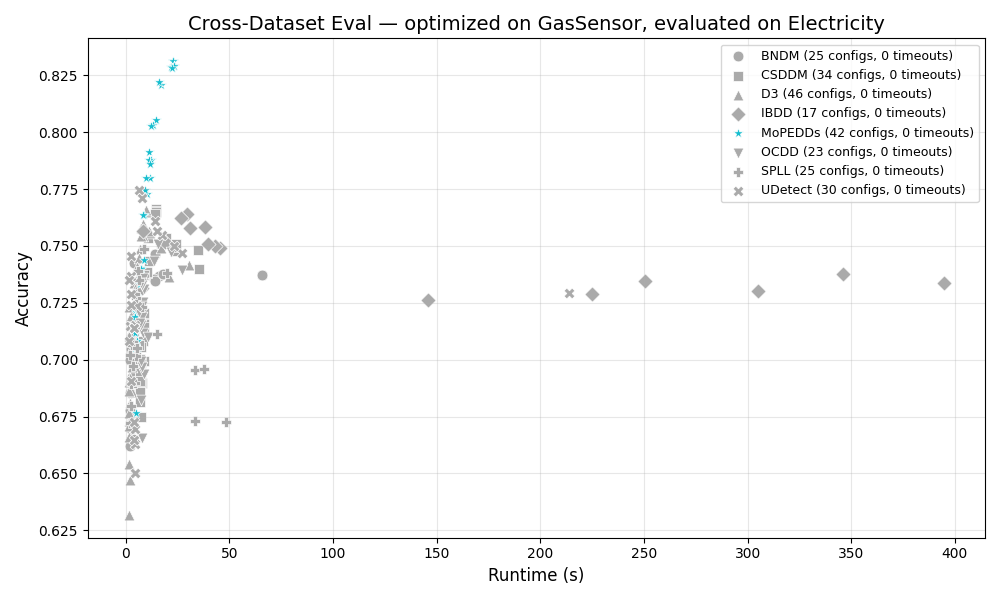

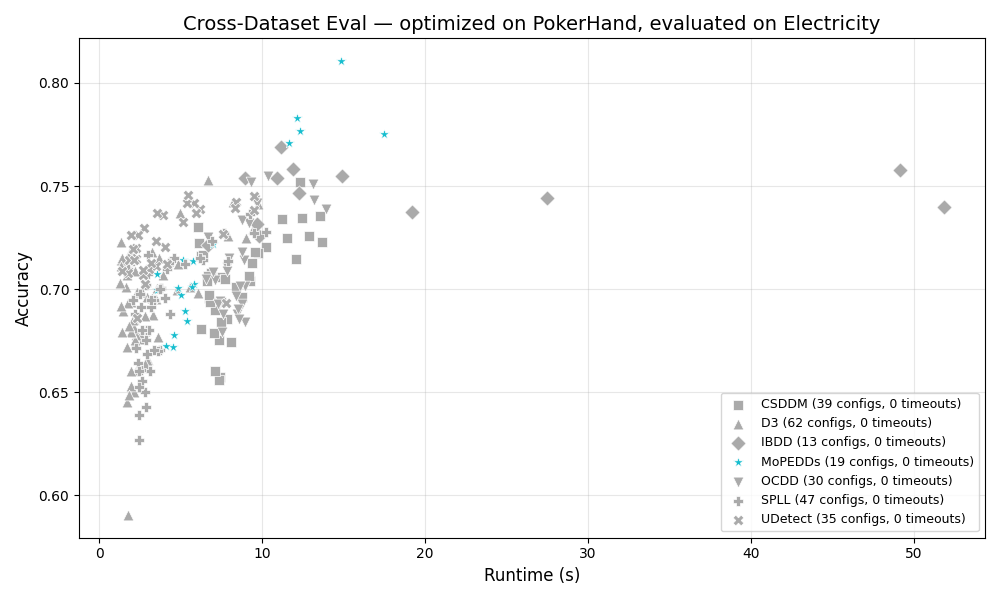

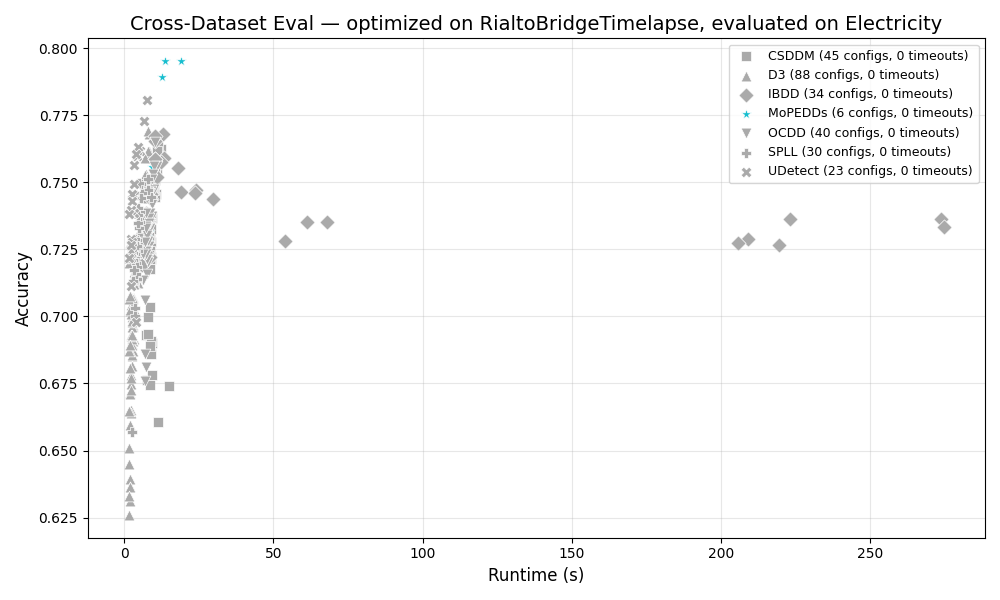

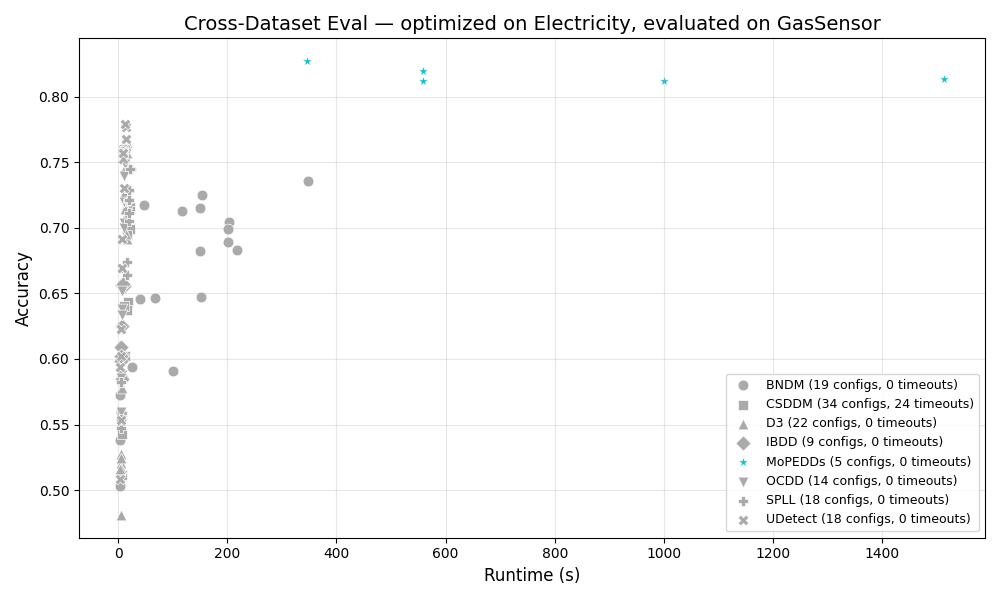

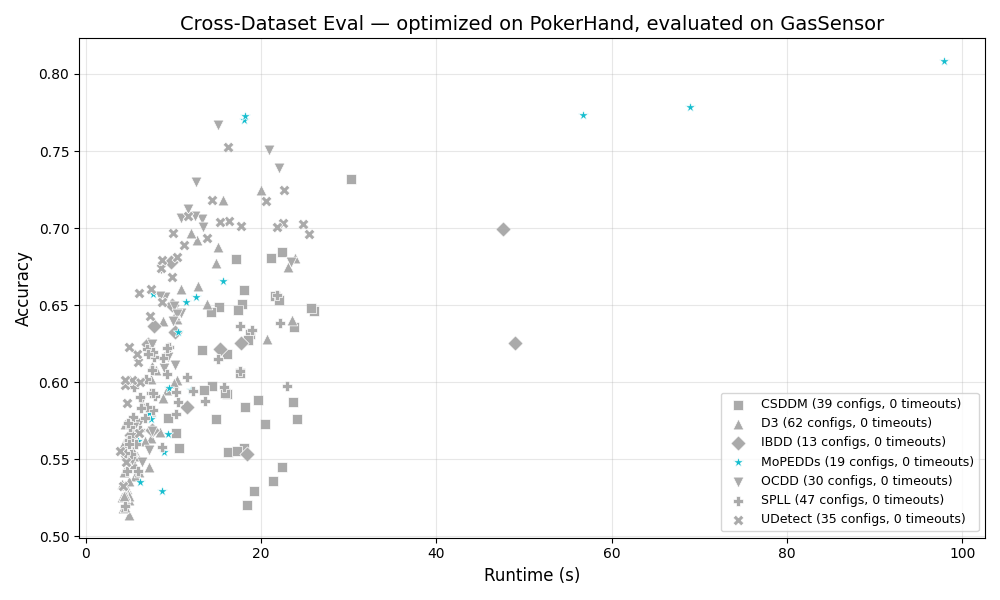

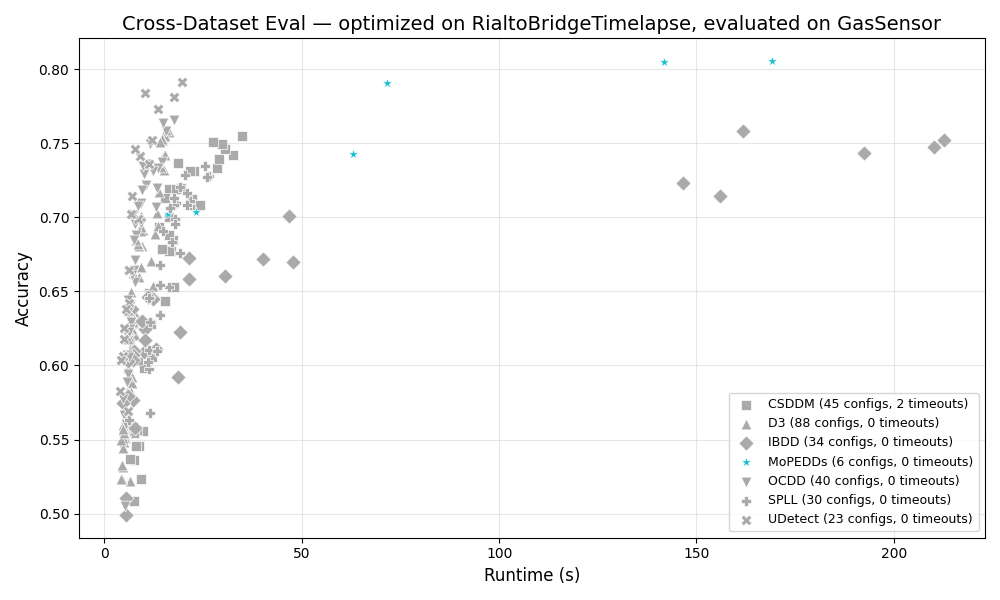

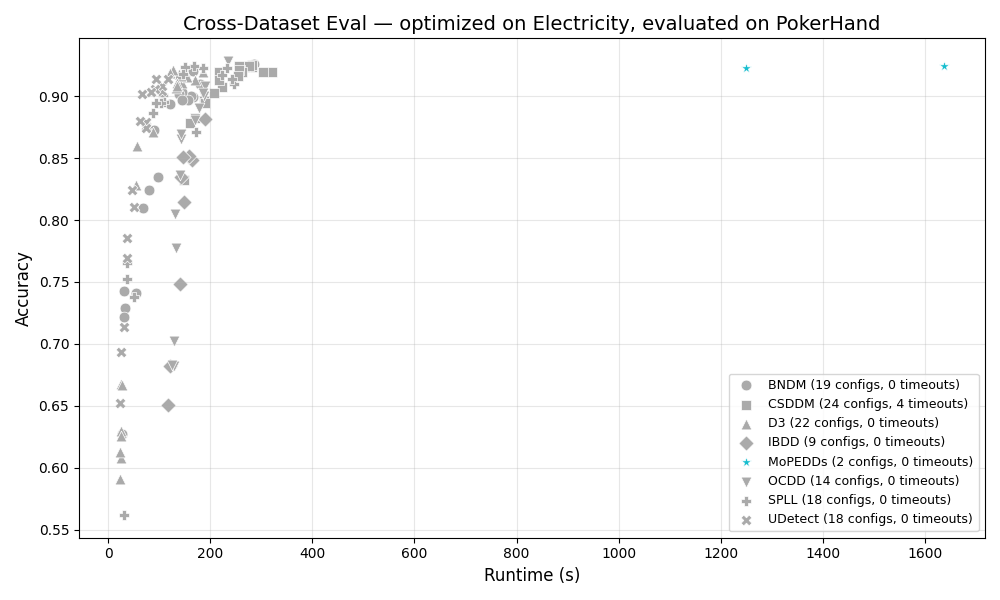

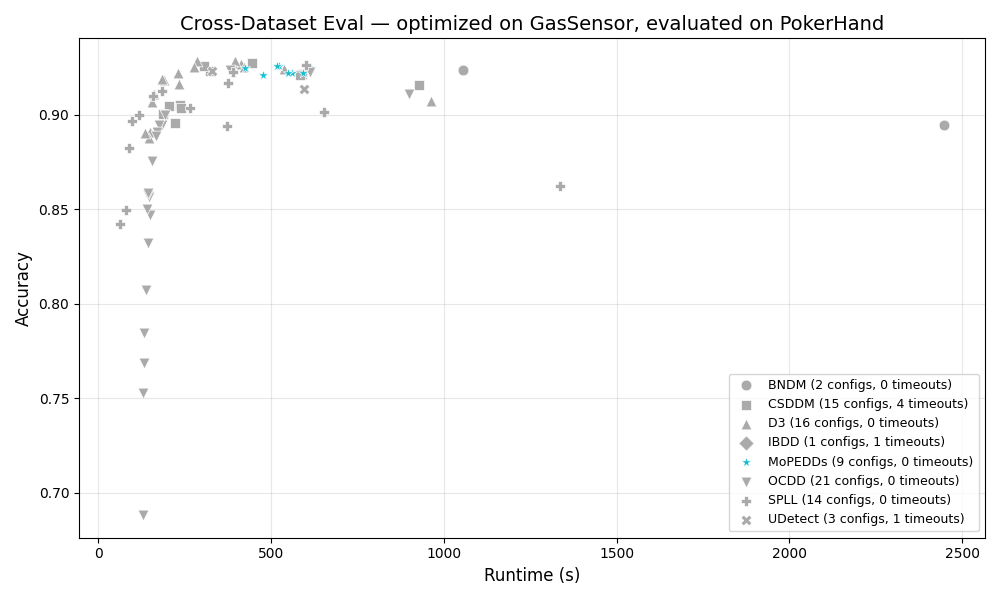

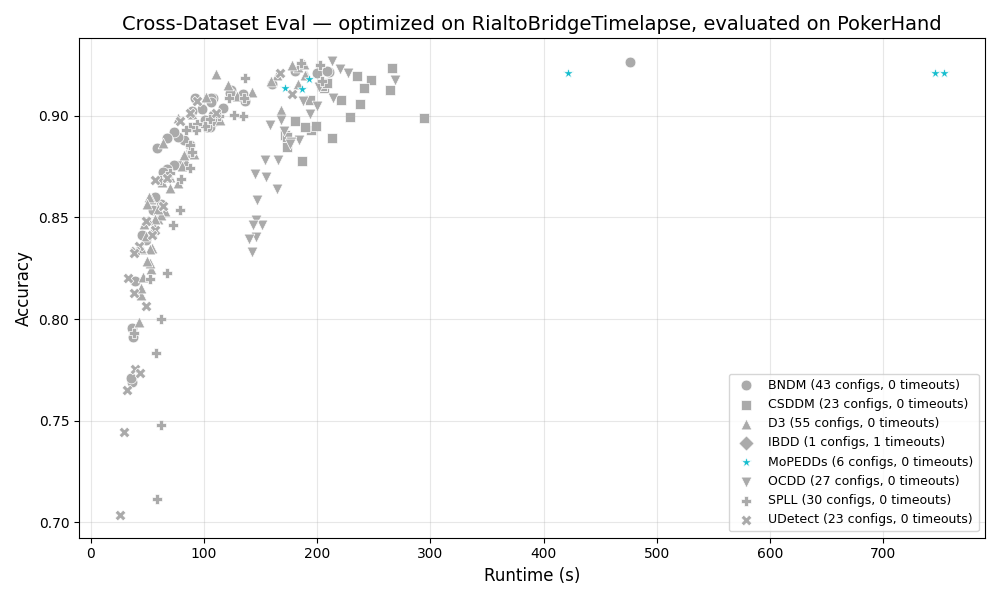

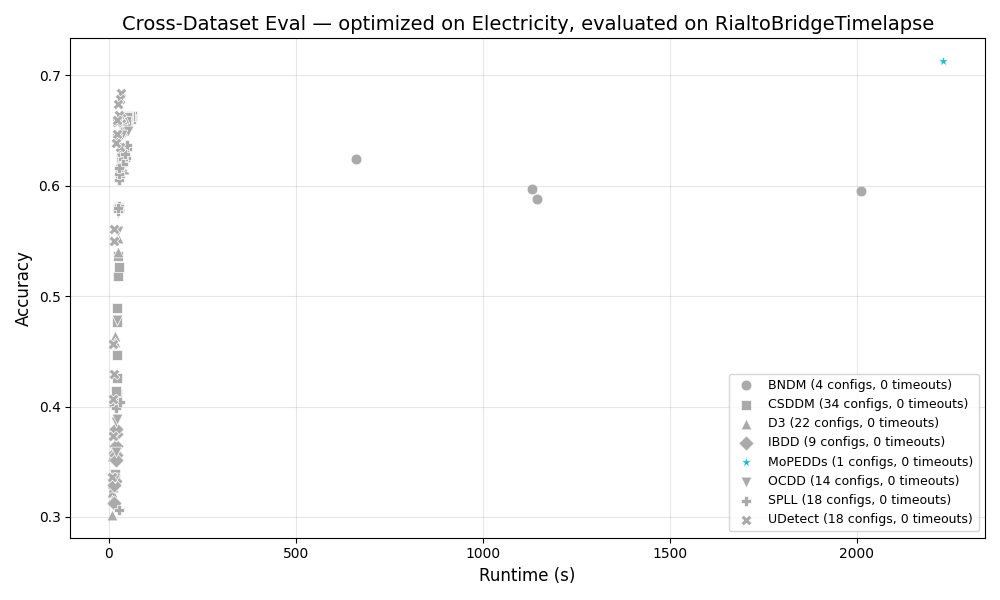

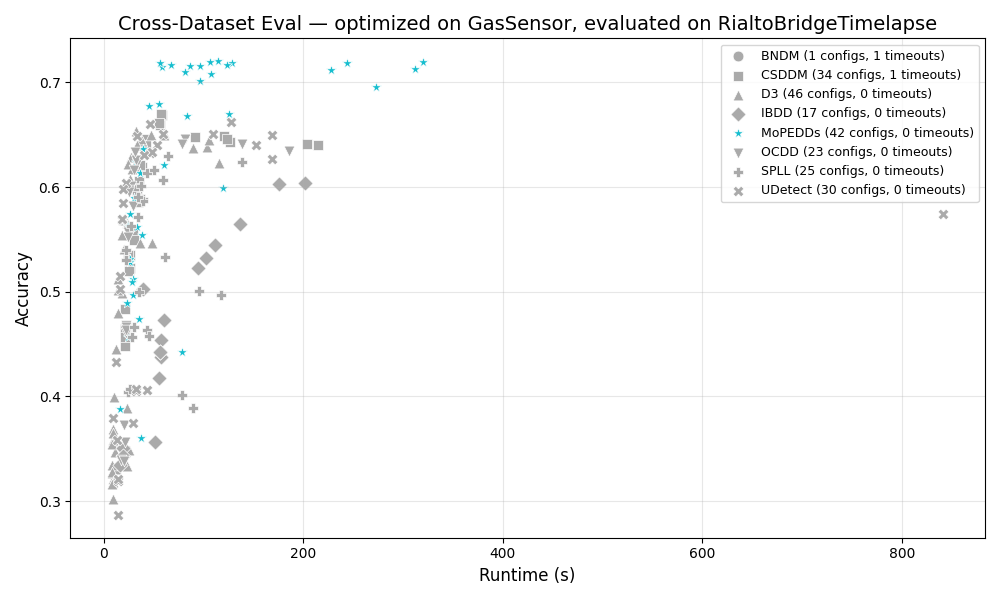

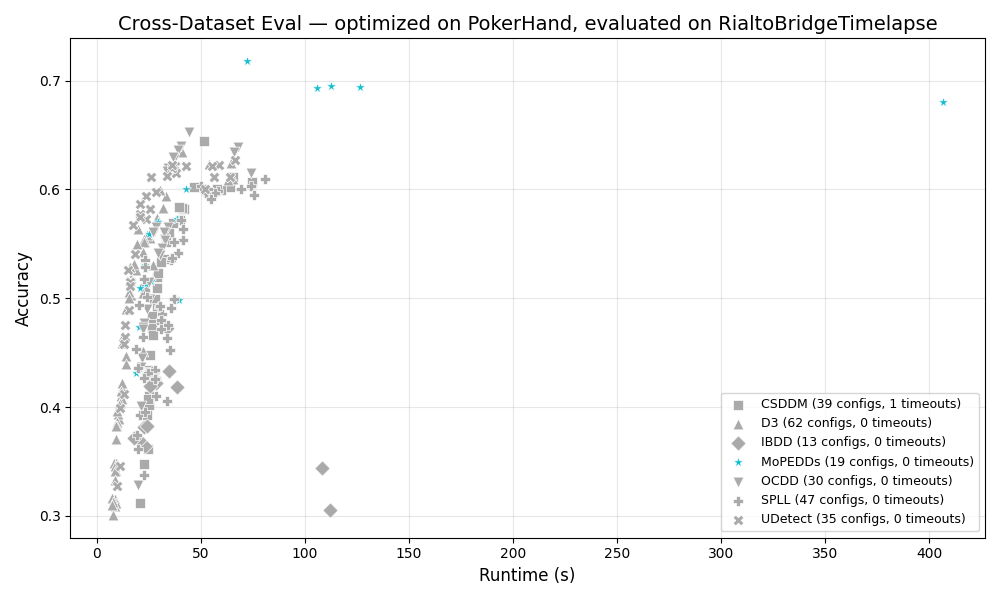

In [141]:
# Breakdown by source dataset: one plot per (eval_dataset, source_dataset) pair
for eval_dataset in sorted(df['eval_dataset'].unique()):
    for source_dataset in sorted(df[df['eval_dataset'] == eval_dataset]['source_dataset'].unique()):
        subset = df[(df['eval_dataset'] == eval_dataset) & (df['source_dataset'] == source_dataset)]
        
        fig, ax = plt.subplots(figsize=(10, 6))
        
        for display_name in sorted(subset['display_detector'].unique()):
            det_df = subset[subset['display_detector'] == display_name]
            
            n_pareto = len(det_df)
            n_timeouts = int(det_df['timeout'].sum())
            
            color = DETECTOR_COLORS.get(display_name, '#333333')
            marker = DETECTOR_MARKERS.get(display_name, 'o')
            
            valid = det_df[det_df['timeout'] == False]
            
            ax.scatter(
                valid['eval_runtime'], valid['eval_accuracy'],
                color=color, marker=marker, s=60,
                edgecolors='white', linewidths=0.5,
                label=f'{display_name} ({n_pareto} configs, {n_timeouts} timeouts)',
            )
        
        ax.set_xlabel('Runtime (s)', fontsize=12)
        ax.set_ylabel('Accuracy', fontsize=12)
        ax.set_title(f'Cross-Dataset Eval \u2014 optimized on {source_dataset}, evaluated on {eval_dataset}',
                     fontsize=14)
        ax.legend(loc='best', fontsize=9)
        ax.grid(True, alpha=0.3)
        fig.tight_layout()
        plt.show()